In [258]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [202]:
url_api = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

response = requests.get(url_api)

if response.status_code == 200:
    raw_data = response.json()

else:
  print("Erro na requisição: ", response.status_code)

In [203]:
dados = pd.DataFrame(raw_data)

In [204]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [205]:
dados

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [206]:
dados['customerID'] = dados['customerID'].astype("string")

In [207]:
dados['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [208]:
dados['Churn'] = dados['Churn'].replace('', np.nan).map({'Yes': 1, 'No': 0}).astype("Int64")

In [209]:
customers = pd.json_normalize(dados["customer"])
customers

,gender,SeniorCitizen,Partner,Dependents,tenure
0,Female,0,Yes,Yes,9
1,Male,0,No,No,9
2,Male,0,No,No,4
3,Male,1,Yes,No,13
4,Female,1,Yes,No,3
...,...,...,...,...,...
7262,Female,0,No,No,13
7263,Male,0,Yes,No,22
7264,Male,0,No,No,2
7265,Male,0,Yes,Yes,67


In [210]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   gender         7267 non-null   object
 1   SeniorCitizen  7267 non-null   int64 
 2   Partner        7267 non-null   object
 3   Dependents     7267 non-null   object
 4   tenure         7267 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 284.0+ KB


In [211]:
customers = customers.astype({
    'gender': 'category',
    'Partner': 'category',
    'Dependents': 'category',
})

In [212]:
phones = pd.json_normalize(dados["phone"])
phones

,PhoneService,MultipleLines
0,Yes,No
1,Yes,Yes
2,Yes,No
3,Yes,No
4,Yes,No
...,...,...
7262,Yes,No
7263,Yes,Yes
7264,Yes,No
7265,Yes,No


In [213]:
phones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PhoneService   7267 non-null   object
 1   MultipleLines  7267 non-null   object
dtypes: object(2)
memory usage: 113.7+ KB


In [214]:
phones = phones.astype({
    'MultipleLines': 'category',
    'PhoneService': 'category',
})

In [215]:
internet = pd.json_normalize(dados["internet"])
internet

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,DSL,No,Yes,No,Yes,Yes,No
1,DSL,No,No,No,No,No,Yes
2,Fiber optic,No,No,Yes,No,No,No
3,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,Fiber optic,No,No,No,Yes,Yes,No
...,...,...,...,...,...,...,...
7262,DSL,Yes,No,No,Yes,No,No
7263,Fiber optic,No,No,No,No,No,Yes
7264,DSL,No,Yes,No,No,No,No
7265,DSL,Yes,No,Yes,Yes,No,Yes


In [216]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   InternetService   7267 non-null   object
 1   OnlineSecurity    7267 non-null   object
 2   OnlineBackup      7267 non-null   object
 3   DeviceProtection  7267 non-null   object
 4   TechSupport       7267 non-null   object
 5   StreamingTV       7267 non-null   object
 6   StreamingMovies   7267 non-null   object
dtypes: object(7)
memory usage: 397.5+ KB


In [217]:
internet = internet.astype({
    'InternetService': 'category',
    'OnlineSecurity': 'category',
    'OnlineBackup': 'category',
    'DeviceProtection': 'category',
    'TechSupport': 'category',
    'StreamingTV': 'category',
    'StreamingMovies': 'category'
})

In [218]:
accounts = pd.json_normalize(dados['account'])
accounts

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,One year,Yes,Mailed check,65.60,593.3
1,Month-to-month,No,Mailed check,59.90,542.4
2,Month-to-month,Yes,Electronic check,73.90,280.85
3,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...
7262,One year,No,Mailed check,55.15,742.9
7263,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,Month-to-month,Yes,Mailed check,50.30,92.75
7265,Two year,No,Mailed check,67.85,4627.65


In [219]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Contract          7267 non-null   object 
 1   PaperlessBilling  7267 non-null   object 
 2   PaymentMethod     7267 non-null   object 
 3   Charges.Monthly   7267 non-null   float64
 4   Charges.Total     7267 non-null   object 
dtypes: float64(1), object(4)
memory usage: 284.0+ KB


In [220]:
accounts = accounts.astype({
    'Contract': 'category',
    'PaperlessBilling': 'category',
    'PaymentMethod': 'category',
})

In [221]:
accounts['Charges.Total'].unique()

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

In [222]:
accounts['Charges.Total'] = pd.to_numeric(accounts['Charges.Total'],errors='coerce')

In [223]:
dados = dados.drop(columns=['customer', 'phone', 'internet', 'account'])

In [224]:
dados

,customerID,Churn
0,0002-ORFBO,0
1,0003-MKNFE,0
2,0004-TLHLJ,1
3,0011-IGKFF,1
4,0013-EXCHZ,1
...,...,...
7262,9987-LUTYD,0
7263,9992-RRAMN,1
7264,9992-UJOEL,0
7265,9993-LHIEB,0


In [225]:
customers = customers.reset_index(drop=True)
phones = phones.reset_index(drop=True)
internet = internet.reset_index(drop=True)
accounts = accounts.reset_index(drop=True)
dados = dados.reset_index(drop=True)

dados = pd.concat(
    [dados, customers, phones, internet, accounts],
    axis=1
)

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7267 non-null   string  
 1   Churn             7043 non-null   Int64   
 2   gender            7267 non-null   category
 3   SeniorCitizen     7267 non-null   int64   
 4   Partner           7267 non-null   category
 5   Dependents        7267 non-null   category
 6   tenure            7267 non-null   int64   
 7   PhoneService      7267 non-null   category
 8   MultipleLines     7267 non-null   category
 9   InternetService   7267 non-null   category
 10  OnlineSecurity    7267 non-null   category
 11  OnlineBackup      7267 non-null   category
 12  DeviceProtection  7267 non-null   category
 13  TechSupport       7267 non-null   category
 14  StreamingTV       7267 non-null   category
 15  StreamingMovies   7267 non-null   category
 16  Contract          7267 n

In [226]:
dados.isna().sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [227]:
dados[dados["Charges.Total"].isna()]["tenure"]

,tenure
975,0
1775,0
1955,0
2075,0
2232,0
2308,0
2930,0
3134,0
3203,0
4169,0


In [228]:
dados["Charges.Total"] = dados["Charges.Total"].fillna(0)

In [232]:
dados = dados.dropna(subset=['Churn'])

In [233]:
dados.isna().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [237]:
dados.duplicated().sum()

np.int64(0)

In [238]:
dados['customerID'].duplicated().sum()

np.int64(0)

In [240]:
for col in dados.select_dtypes("category"):
    print(col, dados[col].unique())

gender ['Female', 'Male']
Categories (2, object): ['Female', 'Male']
Partner ['Yes', 'No']
Categories (2, object): ['No', 'Yes']
Dependents ['Yes', 'No']
Categories (2, object): ['No', 'Yes']
PhoneService ['Yes', 'No']
Categories (2, object): ['No', 'Yes']
MultipleLines ['No', 'Yes', 'No phone service']
Categories (3, object): ['No', 'No phone service', 'Yes']
InternetService ['DSL', 'Fiber optic', 'No']
Categories (3, object): ['DSL', 'Fiber optic', 'No']
OnlineSecurity ['No', 'Yes', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']
OnlineBackup ['Yes', 'No', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']
DeviceProtection ['No', 'Yes', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']
TechSupport ['Yes', 'No', 'No internet service']
Categories (3, object): ['No', 'No internet service', 'Yes']
StreamingTV ['Yes', 'No', 'No internet service']
Categories (3, object): ['No', 'No intern

In [243]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   string  
 1   Churn             7043 non-null   Int64   
 2   gender            7043 non-null   category
 3   SeniorCitizen     7043 non-null   int64   
 4   Partner           7043 non-null   category
 5   Dependents        7043 non-null   category
 6   tenure            7043 non-null   int64   
 7   PhoneService      7043 non-null   category
 8   MultipleLines     7043 non-null   category
 9   InternetService   7043 non-null   category
 10  OnlineSecurity    7043 non-null   category
 11  OnlineBackup      7043 non-null   category
 12  DeviceProtection  7043 non-null   category
 13  TechSupport       7043 non-null   category
 14  StreamingTV       7043 non-null   category
 15  StreamingMovies   7043 non-null   category
 16  Contract          7043 non-nu

In [245]:
dados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [250]:
colunas_binarias = [
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

for col in colunas_binarias:
  dados[col] = dados[col].replace('', np.nan).map({'Yes': 1, 'No': 0}).astype("Int64")
dados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


In [252]:
desc = dados.describe()

colunas_nao_binarias = desc.loc["max"] > 1

desc.loc[:, colunas_nao_binarias]

,tenure,Charges.Monthly,Charges.Total
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [259]:
percentual = dados["Churn"].value_counts(normalize=True) * 100

print(f"Percentual de clientes que não cancelaram: {percentual[0]:.2f}%")
dados["Churn"].value_counts(normalize=True) * 100

Percentual de clientes que não cancelaram: 73.46%


,proportion
Churn,
0,73.463013
1,26.536987


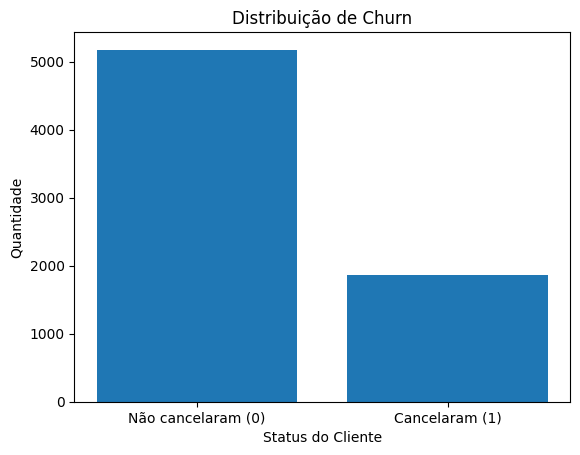

In [260]:
contagem = dados['Churn'].value_counts().sort_index()

plt.figure()
plt.bar(["Não cancelaram (0)", "Cancelaram (1)"], contagem)

plt.title("Distribuição de Churn")
plt.xlabel("Status do Cliente")
plt.ylabel("Quantidade")

plt.show()

In [272]:
dados.groupby("gender", observed=False)["Churn"].mean().sort_values(ascending=False)

,Churn
gender,
Female,0.269209
Male,0.261603


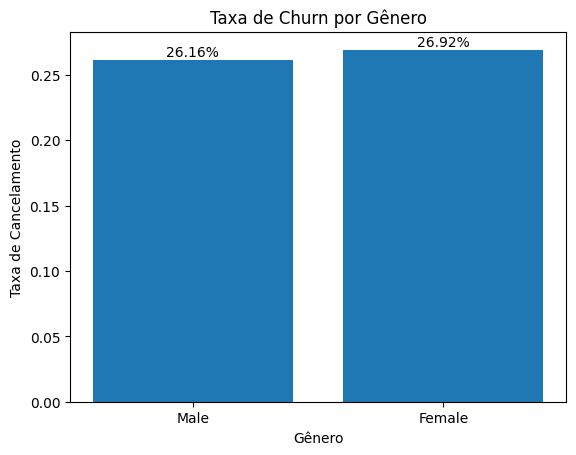

In [275]:
taxa_genero = dados.groupby("gender", observed=False)["Churn"].mean().sort_values()

plt.figure()
bars = plt.bar(taxa_genero.index, taxa_genero)

plt.title("Taxa de Churn por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Taxa de Cancelamento")

for i, bar in enumerate(bars):
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.2%}",
        ha='center',
        va='bottom'
    )

plt.show()

O cancelamento não é influenciado pelo gênero do cliente.

In [264]:
dados.groupby("Contract", observed=False)["Churn"].mean().sort_values(ascending=False)

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


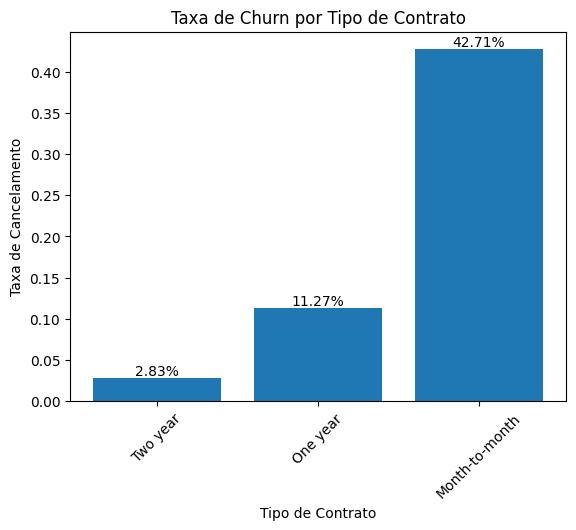

In [274]:
taxa_contrato = dados.groupby("Contract", observed=False)["Churn"].mean().sort_values()

plt.figure()
bars = plt.bar(taxa_contrato.index, taxa_contrato)

plt.title("Taxa de Churn por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Taxa de Cancelamento")

plt.xticks(rotation=45)

for i, bar in enumerate(bars):
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.2%}",
        ha='center',
        va='bottom'
    )

plt.show()

Clientes com contrato mensal apresentam maior taxa de evasão.

In [266]:
dados.groupby("PaymentMethod", observed=False)["Churn"].mean().sort_values(ascending=False)

,Churn
PaymentMethod,
Electronic check,0.452854
Mailed check,0.191067
Bank transfer (automatic),0.167098
Credit card (automatic),0.152431


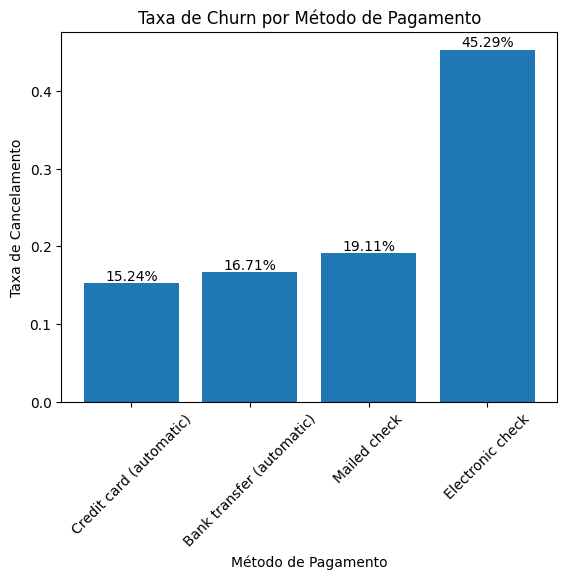

In [276]:
taxa_pagamento = dados.groupby("PaymentMethod", observed=False)["Churn"].mean().sort_values()

plt.figure()
bars = plt.bar(taxa_pagamento.index, taxa_pagamento)

plt.title("Taxa de Churn por Método de Pagamento")
plt.xlabel("Método de Pagamento")
plt.ylabel("Taxa de Cancelamento")

plt.xticks(rotation=45)

for i, bar in enumerate(bars):
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.2%}",
        ha='center',
        va='bottom'
    )

plt.show()

Clientes com pagamento por meio de cheques eletrônicos tem maior taxa de evasão.

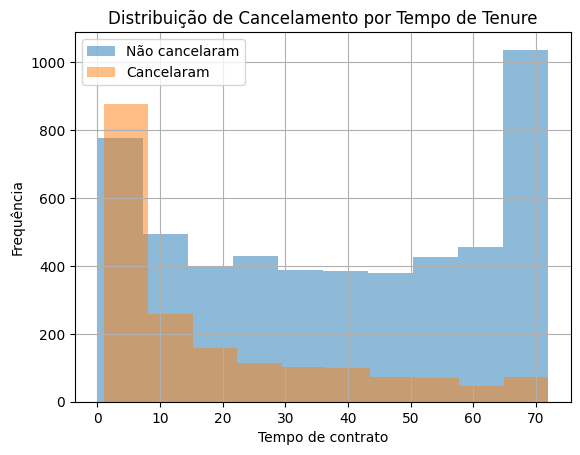

In [283]:
plt.figure()

dados[dados["Churn"] == 0]["tenure"].hist(alpha=0.5)
dados[dados["Churn"] == 1]["tenure"].hist(alpha=0.5)

plt.title("Distribuição de Cancelamento por Tempo de Tenure")
plt.xlabel("Tempo de contrato")
plt.ylabel("Frequência")

plt.legend(["Não cancelaram", "Cancelaram"])
plt.show()

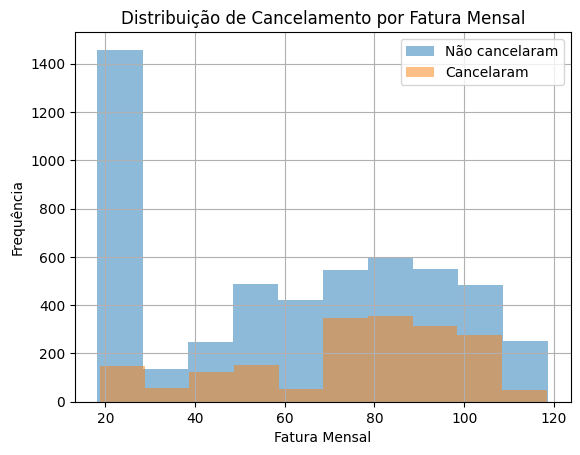

In [285]:
plt.figure()

dados[dados["Churn"] == 0]["Charges.Monthly"].hist(alpha=0.5)
dados[dados["Churn"] == 1]["Charges.Monthly"].hist(alpha=0.5)

plt.title("Distribuição de Cancelamento por Fatura Mensal")
plt.xlabel("Fatura Mensal")
plt.ylabel("Frequência")

plt.legend(["Não cancelaram", "Cancelaram"])
plt.show()

#RELATÓRIO FINAL – ANÁLISE DE EVASÃO DE CLIENTES (CHURN)

---


##1️⃣ Introdução
###📌 Contexto

A evasão de clientes (Churn) é um dos principais desafios enfrentados por empresas de telecomunicações, pois impacta diretamente a receita e a sustentabilidade do negócio.

O objetivo desta análise é:
*   Explorar os dados dos clientes
*   Identificar padrões de evasão
*   Entender que fatores influenciam o cancelamento
*   Gerar insights para retenção

A variável alvo utilizada foi Churn, codificada como:

0 → Cliente permaneceu

1 → Cliente cancelou


---


##2️⃣ Limpeza e Tratamento de Dados

Durante a preparação dos dados, foram realizados os seguintes passos:


*   Importação de dados via API (.json)
*   Conversão para DataFrame utilizando pandas
*   Tratamento de valores ausentes
*   Conversão de tipos de dados
*   Variáveis binárias (Não e Sim) convertidas para formato numérico (0 e 1)
*   Não foram encontrados valores duplicados

Resultado: dataset pronto para análise exploratória.


---


##3️⃣ Análise Exploratória de Dados (EDA)
###📊 Distribuição da Variável Churn

Observou-se que aproximadamente:

~73% dos clientes permaneceram

~27% cancelaram

Isso indica um leve desbalanceamento da variável alvo.

###📊 Análise por Variáveis Categóricas
####🔹 Tipo de Contrato

*   Clientes com contrato mensal (Month-to-month) apresentaram taxa significativamente maior de cancelamento.

*   Clientes com contratos de 1 ou 2 anos possuem taxas muito menores de evasão.

#####👉 Insight: contratos longos aumentam retenção.

####🔹 Método de Pagamento

*   Foi observado que determinados métodos de pagamento (como cheque eletrônico) apresentam maior taxa de evasão.

*   Pagamentos automáticos tendem a reduzir o churn.

#####👉 Insight: automação aumenta fidelização.

####🔹 Gênero

A diferença entre gêneros foi pequena, indicando que essa variável não é um forte preditor isolado de churn.

###📊 Análise por Variáveis Numéricas
####🔹 Tempo de Contrato (tenure)

Clientes que cancelaram possuem tempo médio de permanência significativamente menor.

#####👉 A evasão ocorre principalmente nos primeiros meses.

####🔹 Total Gasto

Clientes que cancelaram possuem menor valor acumulado gasto, reforçando que a maior evasão ocorre no início do relacionamento.


---


##4️⃣ Conclusões e Insights

Com base na análise realizada, os principais fatores associados à evasão são:

*   Contratos mensais apresentam maior risco
*   Clientes com pouco tempo de contrato têm maior probabilidade de cancelar
*   Métodos de pagamento não automáticos estão associados a maior churn
*   Clientes nos primeiros meses representam grupo crítico de retenção

A variável mais forte identificada foi o tipo de contrato, seguida do tempo de permanência.


---


##5️⃣ Recomendações Estratégicas

Com base nos insights obtidos, recomenda-se:

🎯 1. Incentivar contratos de longo prazo

*   Oferecer descontos progressivos
*   Benefícios exclusivos para contratos anuais

🎯 2. Criar programa de retenção nos primeiros meses

*   Contato ativo com novos clientes
*   Ofertas personalizadas
*   Monitoramento de satisfação

🎯 3. Incentivar pagamento automático

*   Desconto para débito automático
*   Benefícios adicionais

🎯 4. Desenvolver modelo preditivo

Com as variáveis identificadas, é possível desenvolver um modelo de Machine Learning para prever churn e agir preventivamente.


---


##📌 Considerações Finais

A análise exploratória permitiu identificar padrões relevantes no comportamento de cancelamento dos clientes. Esses insights podem orientar estratégias de retenção mais eficientes e baseadas em dados, reduzindo perdas financeiras e aumentando o lifetime value dos clientes.